In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [5]:
data = pd.read_csv("adm_data.csv")
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [33]:
x = data[['GRE Score','TOEFL Score','University Rating','SOP','LOR ','CGPA','Research']]
y = data['Chance of Admit ']

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
x_train.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
3,322,110,3,3.5,2.5,8.67,1
18,318,110,3,4.0,3.0,8.80,0
202,340,120,5,4.5,4.5,9.91,1
250,320,104,3,3.0,2.5,8.57,1
274,315,100,1,2.0,2.5,7.95,0


In [35]:
y_train.head()

3      0.80
18     0.63
202    0.97
250    0.74
274    0.58
Name: Chance of Admit , dtype: float64

In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [36]:
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.7).astype(int)
print(y_test[:5])
print(y_pred[:5])

209    0.68
280    0.68
33     0.90
210    0.79
93     0.44
Name: Chance of Admit , dtype: float64
[0 1 1 1 0]


C:\Users\MY-NAME\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [37]:
mse = mean_squared_error(y_test, y_pred)
print("mean squared error: ",mse)

mean squared error:  0.17187375


In [38]:
plot_model = LogisticRegression(max_iter=1000)
plot_model.fit(y_test.values.reshape(-1,1), y_pred)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
y_plot = plot_model.predict(y_test.values.reshape(-1,1))

In [40]:
y_range = np.linspace(0, 7, 80).reshape(-1, 1)
y_prob = plot_model.predict_proba(y_range)[:, 1]

C:\Users\MY-NAME\AppData\Local\Temp\ipykernel_11136\4045088829.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


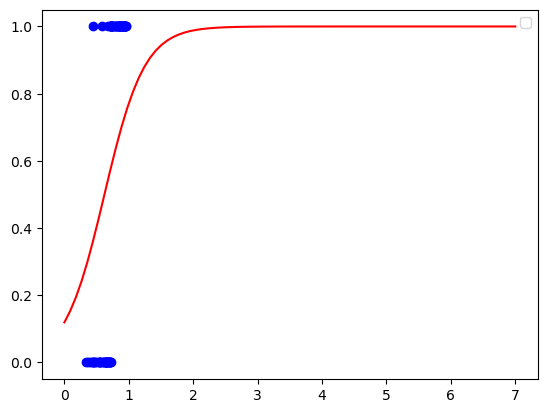

In [41]:
plt.scatter(y_test, y_pred, color="blue")
plt.plot(y_range, y_prob, color='red')
plt.legend()
plt.show()